<a href="https://colab.research.google.com/github/flipiwolker-alt/cv-video-analytics/blob/main/notebooks/PZ_5_YOLO_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ПЗ 5 — Детекция объектов YOLO

Прогоняем кадры из Drive через YOLOv8, сохраняем bounding boxes и классы.

In [19]:
!pip install ultralytics opencv-python-headless pandas tqdm -q

In [20]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

BASE_DRIVE  = '/content/drive/MyDrive/cv-frames'
VIDEO_DIR   = f'{BASE_DRIVE}/видио'
FRAMES_DIR  = f'{BASE_DRIVE}/кадры'
RESULTS_DIR = f'{BASE_DRIVE}/результаты'

for d in [VIDEO_DIR, FRAMES_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)
frames = sorted(f for f in os.listdir(FRAMES_DIR) if f.endswith('.jpg'))
print(f'кадров: {len(frames)}')

Mounted at /content/drive
кадров: 438


In [21]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm

CONF = 0.4
rows = []

for fname in tqdm(frames, desc='yolo'):
    res = model(f'{FRAMES_DIR}/{fname}', conf=CONF, verbose=False)
    for r in res:
        for box in r.boxes:
            rows.append({
                'frame':     fname,
                'frame_num': int(fname.split('_')[1].split('.')[0]),
                'class':     model.names[int(box.cls[0])],
                'conf':      round(float(box.conf[0]), 3),
                'x1': round(float(box.xyxy[0][0])),
                'y1': round(float(box.xyxy[0][1])),
                'x2': round(float(box.xyxy[0][2])),
                'y2': round(float(box.xyxy[0][3])),
            })

df = pd.DataFrame(rows)
df.to_csv(f'{RESULTS_DIR}/yolo_detections.csv', index=False)
print(f'детекций: {len(df)}')
df.head(10)

In [23]:
print(df.groupby('class')['conf'].agg(['count', 'mean']).sort_values('count', ascending=False))

              count      mean
class                        
person          489  0.823697
tie              20  0.518500
cell phone       18  0.649333
chair            14  0.571571
potted plant      2  0.694000
donut             2  0.522000
bird              2  0.487500
wine glass        2  0.653000
cup               1  0.463000
bottle            1  0.438000
cat               1  0.588000
dining table      1  0.530000
teddy bear        1  0.594000
umbrella          1  0.590000
vase              1  0.406000


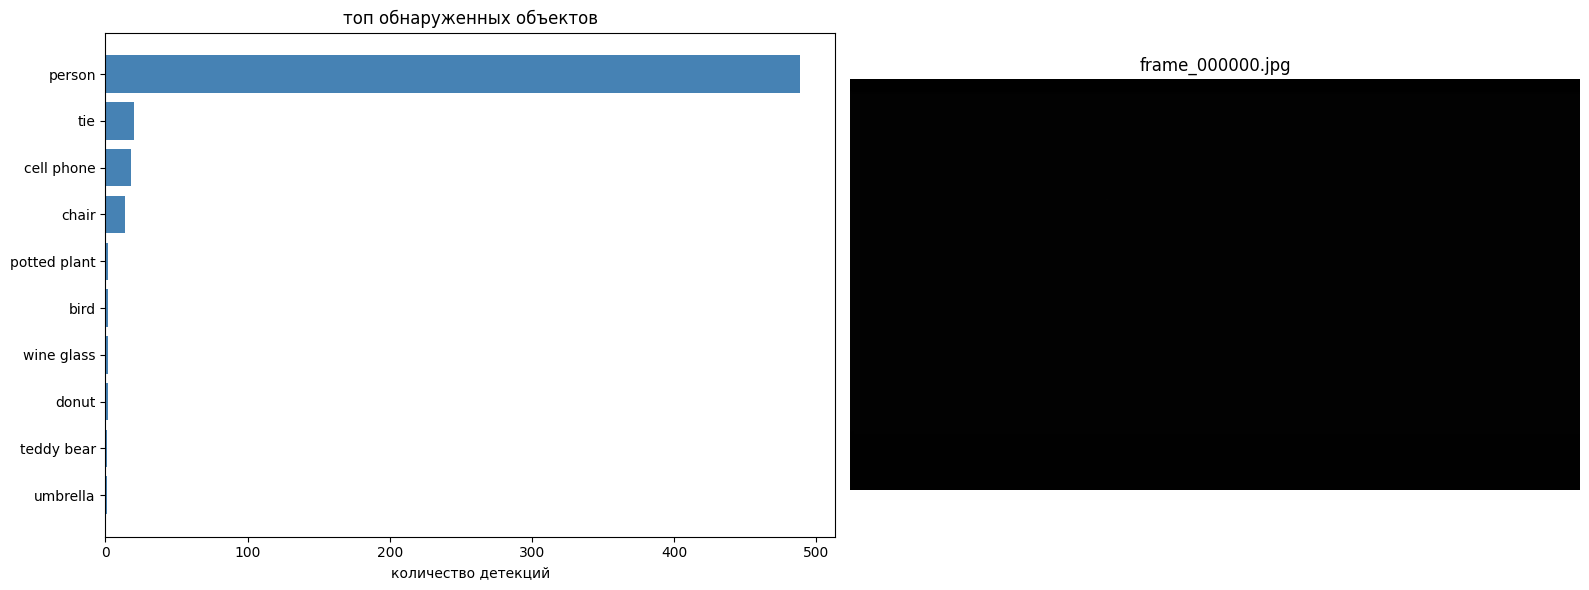

график сохранён в drive


In [24]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# топ обнаруженных классов
top = df['class'].value_counts().head(10)
axes[0].barh(top.index[::-1], top.values[::-1], color='steelblue')
axes[0].set_title('топ обнаруженных объектов')
axes[0].set_xlabel('количество детекций')

# первый кадр с рамками
img = cv2.imread(f'{FRAMES_DIR}/{frames[0]}')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axes[1].imshow(img_rgb)

for _, row in df[df['frame'] == frames[0]].iterrows():
    rect = mpatches.Rectangle(
        (row.x1, row.y1), row.x2 - row.x1, row.y2 - row.y1,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    axes[1].add_patch(rect)
    axes[1].text(row.x1, row.y1 - 5, f"{row['class']} {row.conf:.2f}",
                 color='red', fontsize=9, backgroundcolor='white')

axes[1].axis('off')
axes[1].set_title(frames[0])

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/yolo_summary.png', dpi=100, bbox_inches='tight')
plt.show()

print('график сохранён в drive')


самый загруженный кадр: frame_002550.jpg (5 объектов)


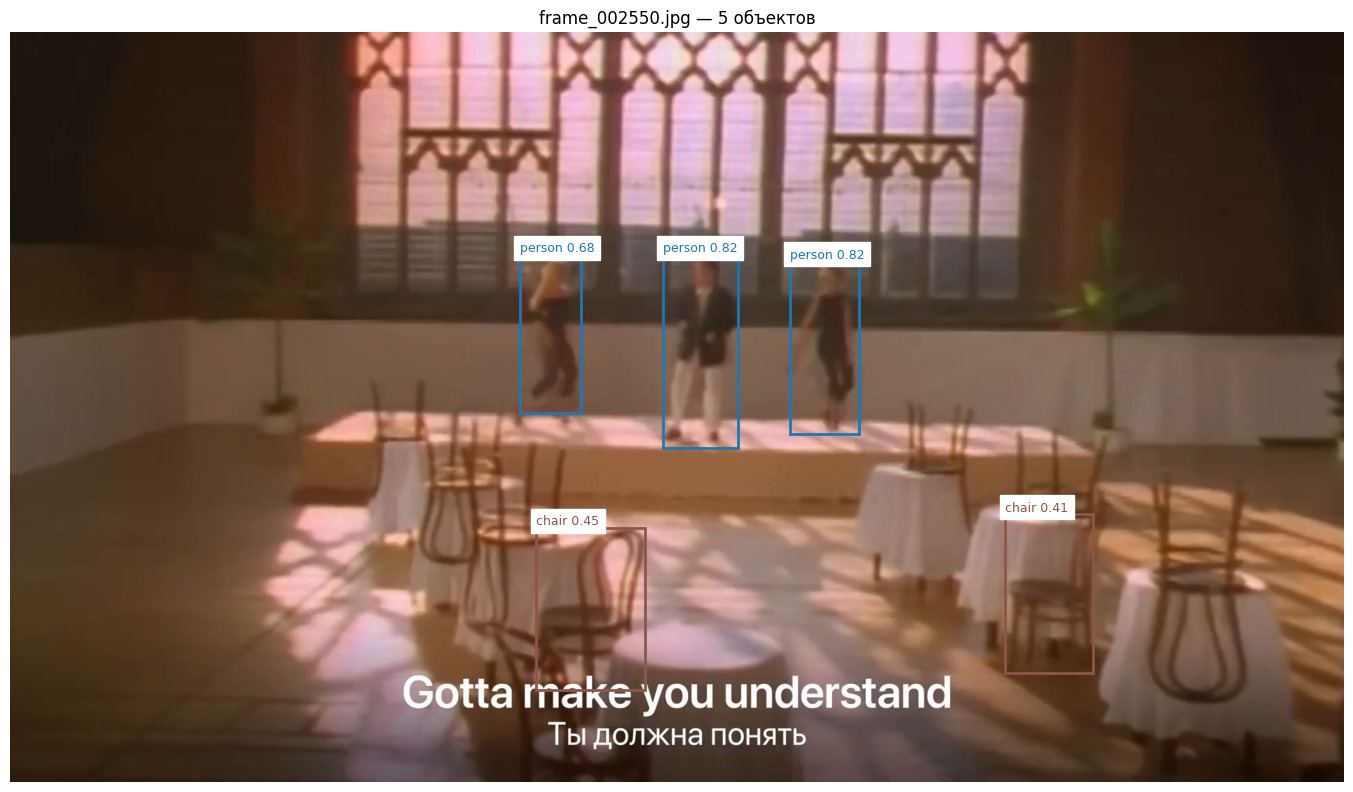

In [25]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# самый загруженный кадр
busiest = df.groupby('frame').size().idxmax()
count   = df.groupby('frame').size().max()
print(f'самый загруженный кадр: {busiest} ({count} объектов)')

img = cv2.imread(f'{FRAMES_DIR}/{busiest}')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img_rgb)

colors = plt.cm.tab10.colors
classes = df['class'].unique().tolist()

for _, row in df[df['frame'] == busiest].iterrows():
    color = colors[classes.index(row['class']) % len(colors)]
    rect = mpatches.Rectangle(
        (row.x1, row.y1), row.x2 - row.x1, row.y2 - row.y1,
        linewidth=2, edgecolor=color, facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(row.x1, row.y1 - 5, f"{row['class']} {row.conf:.2f}",
            color=color, fontsize=9, backgroundcolor='white')

ax.axis('off')
ax.set_title(f'{busiest} — {count} объектов')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/busiest_frame.png', dpi=100, bbox_inches='tight')
plt.show()
